# Rotating Lawn Sprinkler Simulation
This Program calculates the characteristics of a rotating lawn sprinkler.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Parameters

In [2]:
dD  = 0.004                                                   # Exit diameter in meters
AD  = np.pi/4 * dD**2                                         # Exit area in m^2
din = 0.0125                                                  # Entry diameter in meters
Ain = np.pi/4 * din**2                                        # Entry area in m^2
R   = 0.30                                                    # Half arm length in meters
Q   = 0.1e-3                                                  # Flow in m^3/s (1/10 liter per second)
phi = np.deg2rad(10)                                          # Angle to tangent in radians
rho = 1e3                                                     # Density in kg/m^3
omeg= 0.5                                                     # Rotation speed in 1/s = 30min^-1
pL  = 1013e2                                                  # Atmospheric pressure in Pa
eta = Q*R*rho*(Q*np.cos(phi)/2/AD - R)                        # Friction torque in Nms
p   = pL + 0.5*rho*(Q**2/AD**2 - omeg**2*R**2 - Q**2/Ain**2)  # Pressure in Pa

## Calculate rotation speed

In [3]:
eta = 10
Qvec   = np.linspace(0.01e-3, 0.5e-3, 40)  # Flow vector
dDvec  = np.linspace(0.002, 0.006, 5)      # Nozzle diameters
ADvec  = np.pi/4 * dDvec**2

#omega is rotation speed as function of flow rate and nozzle diameter
omega = np.zeros((len(ADvec), len(Qvec)))
for k in range(len(ADvec)):
    omega[k, :] = Qvec * np.cos(phi) / ADvec[k] / 2 / R**2 / (1 + eta / Qvec / rho / R**2)

omegvec = omega.copy()
Deltap = omega.copy()  # placeholder, same shape as omega

## Visualization of rotation speed vs flow

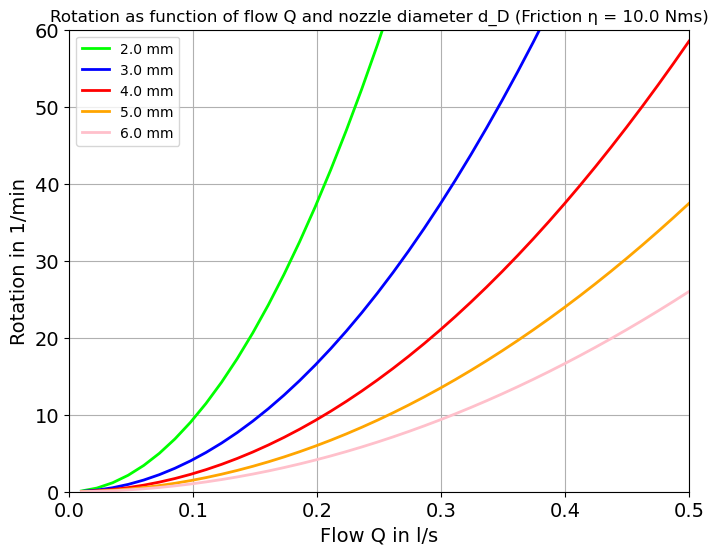

In [4]:
Colors = ['lime','blue', 'red', 'orange', 'pink']
plt.figure(figsize=(8,6))
for k in range(len(ADvec)):
    plt.plot(Qvec*1000, omega[k,:]*60, color=Colors[k], linewidth=2)

    # Legend string for each nozzle diameter
    lgdstr = [f'{d*1000:.1f} mm' for d in dDvec]

plt.xlabel('Flow Q in l/s', fontsize=14)
plt.ylabel('Rotation in 1/min', fontsize=14)
plt.grid(True)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlim(0,0.5)
plt.ylim(0,60)
str_eta = f'{eta:.1f} Nms'
plt.title(f'Rotation as function of flow Q and nozzle diameter d_D (Friction η = {str_eta})', fontsize=12, fontweight='normal')
plt.legend(lgdstr, loc='upper left')

## Calculate pressure

In [5]:
eta = 10
dD  = 0.005
AD  = np.pi/4 * dD**2
etavec = np.linspace(5,25,5)/60  # Friction coefficients in Nms

# pressure as function of flow rate and friction
omegvec = np.zeros((len(etavec), len(Qvec)))
Deltap  = np.zeros((len(etavec), len(Qvec)))

for k in range(len(etavec)):
    omegvec[k,:] = Qvec * np.cos(phi) / AD / 2 / R**2 / (1 + etavec[k] / Qvec / rho / R**2)
    Deltap[k,:]  = 0.5*rho*(Qvec**2/AD**2 - Qvec**2/Ain**2 - omegvec[k,:]**2 * R**2)
    Deltap[k,:]  = 1 + Deltap[k,:]/pL

## Visualization of overpressure vs flow

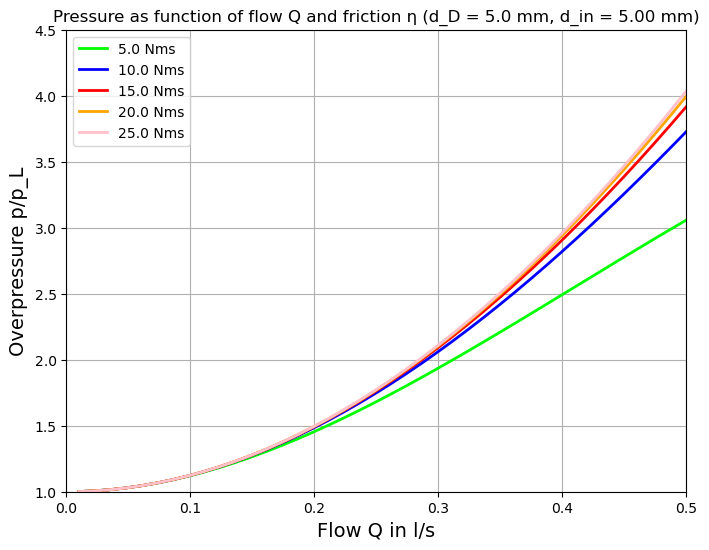

In [6]:
plt.figure(figsize=(8,6))
for k in range(len(etavec)):
    plt.plot(Qvec*1000, Deltap[k,:], color=Colors[k], linewidth=2)
    lgdstr = [f'{e*60:.1f} Nms' for e in etavec]

plt.xlabel('Flow Q in l/s', fontsize=14)
plt.ylabel('Overpressure p/p_L', fontsize=14)
plt.xlim(0,0.5)
plt.ylim(1,4.5)
plt.grid(True)
strD  = f'{dD*1000:.1f} mm'
strin = f'{dD*1000:.2f} mm'
plt.title(f'Pressure as function of flow Q and friction η (d_D = {strD}, d_in = {strin})', fontsize=12, fontweight='normal')
plt.legend(lgdstr, loc='upper left')